## Problem Understanding

The goal of this analysis is to estimate instructor effectiveness using learner outcomes, engagement metrics, and feedback.

Each row in the dataset represents a course batch taught by an instructor. Since instructors may teach multiple batches, we aggregate batch-level data to instructor-level data.

We define an Instructor Effectiveness Score using outcome, engagement, and feedback variables and then classify instructors into three tiers:
Low, Medium, and High effectiveness.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
data = pd.read_csv("instructor_effectiveness_dataset_2000_rows - instructor_effectiveness_dataset_2000_rows.csv.csv")

data.head()

,batch_id,instructor_id,course_id,completion_rate,avg_score_improvement,avg_quiz_score,dropout_rate,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate
0,B_1861,I_044,C_01,0.300000,14.225955,73.546528,0.647423,0.774572,0.790918,0.108414,3.766211,0.533193
1,B_0354,I_119,C_06,0.657220,22.871110,77.312331,0.425098,0.494936,0.998566,0.280550,5.000000,0.734087
2,B_1334,I_050,C_03,0.300000,16.087517,79.563687,0.700000,0.977901,0.807298,0.207013,3.517386,0.681433
3,B_0906,I_024,C_21,0.639507,24.260687,99.295316,0.334657,0.846515,0.544555,0.306395,4.207578,1.000000
4,B_1290,I_001,C_08,0.527302,31.081556,99.393425,0.521099,0.917450,0.865885,0.252289,4.426230,0.696710


In [ ]:
print(data.shape)

data.info()

data.describe()

(2000, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   batch_id                    2000 non-null   object 
 1   instructor_id               2000 non-null   object 
 2   course_id                   2000 non-null   object 
 3   completion_rate             2000 non-null   float64
 4   avg_score_improvement       2000 non-null   float64
 5   avg_quiz_score              2000 non-null   float64
 6   dropout_rate                2000 non-null   float64
 7   avg_watch_time              2000 non-null   float64
 8   assignment_submission_rate  2000 non-null   float64
 9   forum_activity_rate         2000 non-null   float64
 10  avg_feedback_score          2000 non-null   float64
 11  feedback_response_rate      2000 non-null   float64
dtypes: float64(9), object(3)
memory usage: 187.6+ KB


,completion_rate,avg_score_improvement,avg_quiz_score,dropout_rate,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,0.602808,27.035844,77.956126,0.394883,0.776515,0.753188,0.250300,4.207134,0.736519
std,0.159667,5.716641,10.695618,0.162747,0.145231,0.148058,0.100640,0.419209,0.149412
min,0.300000,6.159240,40.386725,0.020000,0.287440,0.251111,0.000000,2.639915,0.259935
25%,0.489260,23.124673,70.897590,0.280035,0.675076,0.652110,0.179845,3.918986,0.633293
50%,0.603091,26.938629,78.020567,0.394820,0.780330,0.756380,0.249771,4.205989,0.737213
75%,0.712797,30.885600,85.444286,0.511432,0.894242,0.856458,0.319204,4.503437,0.845876
max,0.980000,40.000000,100.000000,0.700000,1.000000,1.000000,0.641111,5.000000,1.000000


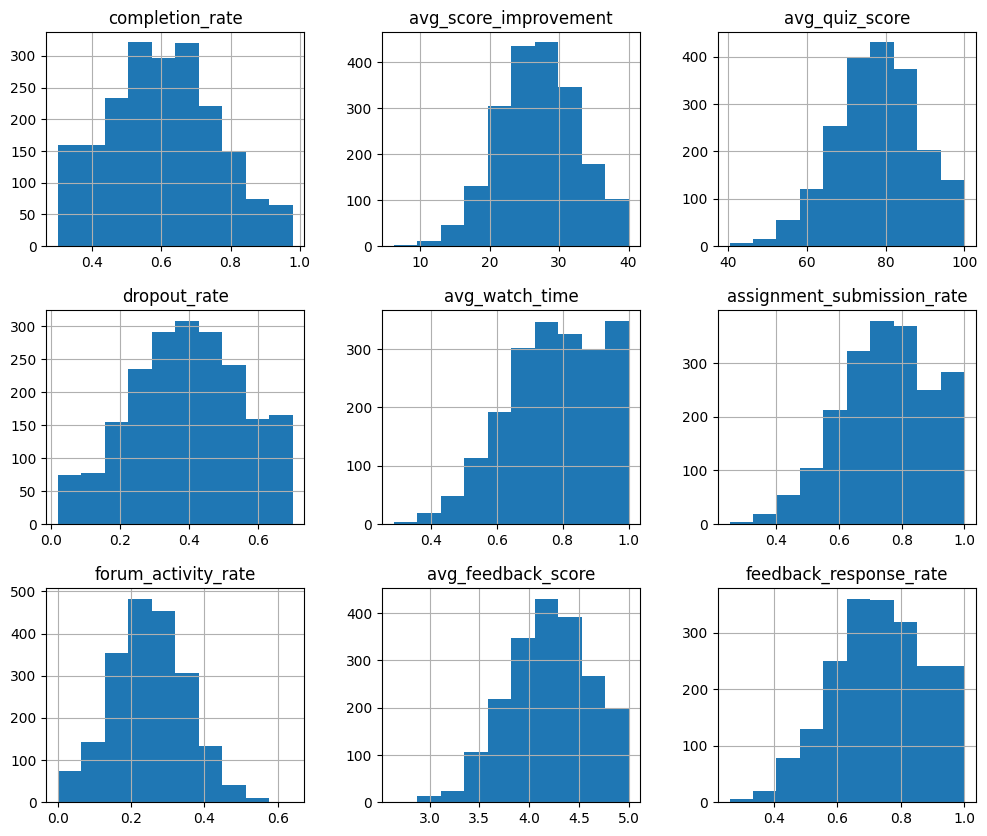

In [ ]:
data.isnull().sum()
data = data.dropna()
data.hist(figsize=(12,10))
plt.show()

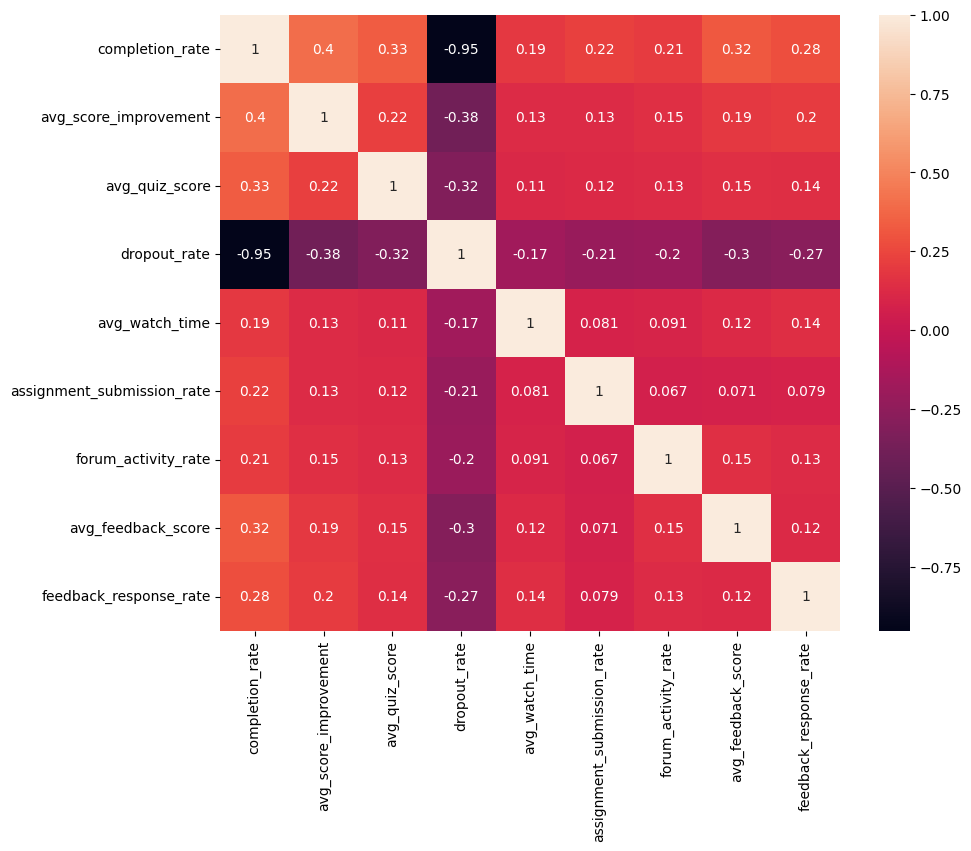

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(data.select_dtypes(include=np.number).corr(),annot=True)
plt.show()

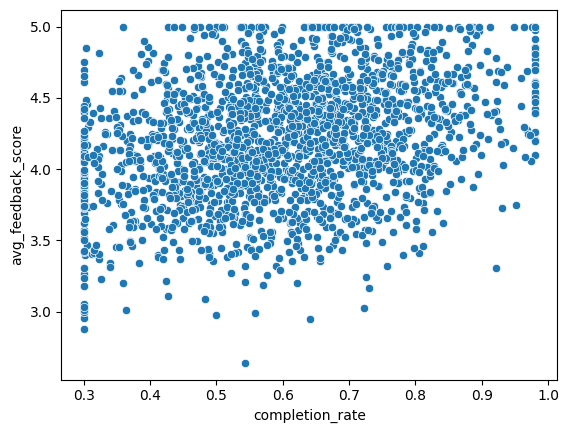

In [ ]:
sns.scatterplot(x="completion_rate",y="avg_feedback_score",data=data)
plt.show()

In [ ]:
data["score"] = (
    data["completion_rate"] +
    (1 - data["dropout_rate"]) +
    data["avg_score_improvement"] +
    data["avg_quiz_score"]/100 +
    data["avg_watch_time"] +
    data["assignment_submission_rate"] +
    data["forum_activity_rate"] +
    data["avg_feedback_score"]/5
) / 8

In [ ]:
data["tier"] = pd.qcut(data["score"],3,labels=["Low","Medium","High"])

## Defining Instructor Effectiveness

Instructor effectiveness is defined using a combined score based on:

- Learner outcomes (completion rate, dropout rate, score improvement)
- Engagement metrics (watch time, assignment submission, forum activity)
- Feedback metrics (feedback score and response rate)

These metrics collectively represent how well learners engage with the course and how successful they are in completing it.

The score is calculated as the average of these normalized metrics to give equal importance to outcomes, engagement, and feedback.

In [ ]:
inst = data.groupby("instructor_id").mean(numeric_only=True).reset_index()

## Aggregating Batch Data to Instructor Level

Since instructors may teach multiple batches, we aggregate batch-level metrics to instructor-level using the mean.

The mean represents the typical performance of an instructor across all batches.

This helps reduce noise from individual batches and provides a more stable estimate of instructor effectiveness.

In [ ]:
inst["tier"] = pd.qcut(inst["score"],3,labels=["Low","Medium","High"])

## EDA Observations

1. Completion rate and dropout rate show an inverse relationship.
2. Higher watch time and assignment submission rates are generally associated with higher feedback scores.
3. Most engagement metrics are moderately correlated with completion rate.
4. Feedback score distribution is slightly skewed towards higher values.

These observations suggest that learner engagement and outcomes are important indicators of instructor effectiveness.

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=1)

In [ ]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier()
model.fit(X_train,y_train)

RandomForestClassifier()

## Model Selection

A Random Forest classifier was used to predict instructor effectiveness tiers.

Reasons for choosing Random Forest:

- Works well with tabular data
- Handles nonlinear relationships
- Provides feature importance for interpretation
- Requires minimal preprocessing

Since the focus of the assignment is reasoning rather than maximizing accuracy, a simple and interpretable model was chosen.

In [ ]:
pred = model.predict(X_test)

In [ ]:
from sklearn.metrics import classification_report,confusion_matrix
print(classification_report(y_test,pred))
print(confusion_matrix(y_test,pred))

              precision    recall  f1-score   support

           0       1.00      0.86      0.92         7
           1       0.78      0.88      0.82         8
           2       0.89      0.89      0.89         9

    accuracy                           0.88        24
   macro avg       0.89      0.87      0.88        24
weighted avg       0.88      0.88      0.88        24

[[6 1 0]
 [0 7 1]
 [0 1 8]]


## Model Evaluation

The model was evaluated using a classification report and confusion matrix.

Metrics used:
- Precision
- Recall
- F1-score

Precision measures how accurate the predicted class labels are, while recall measures how well the model identifies all instances of a class.

A balance between precision and recall is important to avoid misclassifying instructor effectiveness.

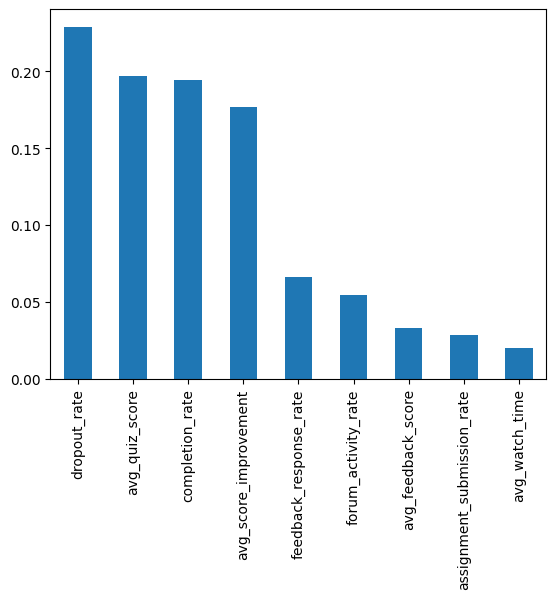

In [ ]:
imp = pd.Series(model.feature_importances_,index=X.columns)
imp.sort_values(ascending=False).plot(kind="bar")
plt.show()

## Key Features Influencing Instructor Effectiveness

Based on feature importance from the model, the most influential variables include:

- Completion rate
- Average score improvement
- Assignment submission rate
- Feedback score

These variables reflect both learning outcomes and student engagement, which are strong indicators of teaching effectiveness.

## How These Insights Could Be Used

The EdTech platform could use these insights to:

- Identify high-performing instructors and replicate their teaching strategies
- Provide training support for instructors with lower effectiveness
- Monitor engagement metrics in real time to detect struggling batches